# Mumbai Housing Data Analysis
This notebook performs the analysis requested in the D1 report using `Mumbai.csv`. The dependent variable is **Price**. The numeric independent variable used for correlation is **Area**, and the categorical independent variable used for chi-square testing is **Location**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv(r"C:\Users\User\Downloads\Mumbai.csv")
df.head()

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,4850000,720,Kharghar,1,1,1,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
1,4500000,600,Kharghar,1,1,1,1,1,0,1,...,1,0,1,0,0,0,0,0,0,0
2,6700000,650,Kharghar,1,1,1,1,1,0,1,...,1,0,1,0,0,0,0,0,0,0
3,4500000,650,Kharghar,1,1,1,0,0,1,0,...,1,1,1,0,0,0,0,0,1,0
4,5000000,665,Kharghar,1,1,1,0,0,1,0,...,1,0,1,0,0,0,0,0,0,0


## 1. Data overview and wrangling

In [2]:
df.shape, df.dtypes.value_counts(), df.isna().sum().sum()

((7719, 40),
 int64     39
 object     1
 Name: count, dtype: int64,
 np.int64(0))

In [3]:
dep = 'Price'
ind_num = 'Area'
ind_cat = 'Location'

def descriptive_stats(data, field):
    s = data[field].dropna()
    mode_vals = s.mode()
    return pd.Series({
        'count': s.count(),
        'mean': s.mean(),
        'median': s.median(),
        'mode': mode_vals.iloc[0] if len(mode_vals) else np.nan,
        'std_dev': s.std(ddof=1),
        'variance': s.var(ddof=1),
        'min': s.min(),
        'q1': s.quantile(0.25),
        'q3': s.quantile(0.75),
        'iqr': s.quantile(0.75)-s.quantile(0.25),
        'max': s.max(),
        'range': s.max()-s.min(),
        'skewness': s.skew(),
        'kurtosis': s.kurtosis()
    })

full_stats = descriptive_stats(df, dep)
full_stats

count       7.719000e+03
mean        1.506165e+07
median      9.500000e+06
mode        8.500000e+06
std_dev     2.052100e+07
variance    4.211114e+14
min         2.000000e+06
q1          5.300000e+06
q3          1.700000e+07
iqr         1.170000e+07
max         4.200000e+08
range       4.180000e+08
skewness    7.241783e+00
kurtosis    9.154110e+01
dtype: float64

## 2. Random sampling (n=150)

In [4]:
random_sample = df.sample(n=150, random_state=42, replace=False)
random_stats = descriptive_stats(random_sample, dep)
random_stats

count       1.500000e+02
mean        1.739321e+07
median      9.100000e+06
mode        8.500000e+06
std_dev     2.422350e+07
variance    5.867781e+14
min         2.000000e+06
q1          6.046500e+06
q3          1.937500e+07
iqr         1.332850e+07
max         1.800000e+08
range       1.780000e+08
skewness    4.180893e+00
kurtosis    2.146019e+01
dtype: float64

## 3. Systematic sampling (n=150)

In [5]:
k = len(df)//150
systematic_sample = df.iloc[0::k].head(150)
systematic_stats = descriptive_stats(systematic_sample, dep)
k, systematic_stats

(51,
 count       1.500000e+02
 mean        1.697125e+07
 median      1.000000e+07
 mode        1.100000e+07
 std_dev     3.389285e+07
 variance    1.148725e+15
 min         2.000000e+06
 q1          5.748500e+06
 q3          1.637500e+07
 iqr         1.062650e+07
 max         3.600000e+08
 range       3.580000e+08
 skewness    7.907669e+00
 kurtosis    7.418587e+01
 dtype: float64)

## 4. Visualisation

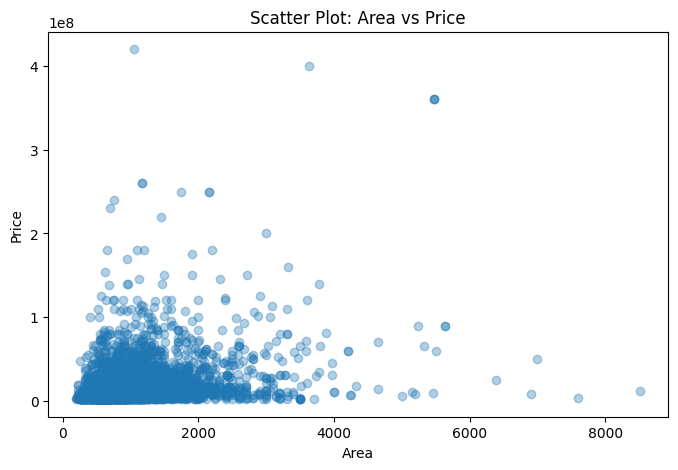

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(df['Area'], df['Price'], alpha=0.35)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Scatter Plot: Area vs Price')
plt.show()

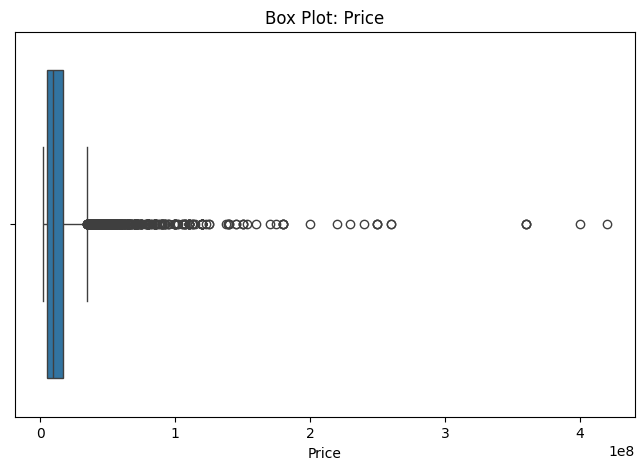

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title('Box Plot: Price')
plt.show()

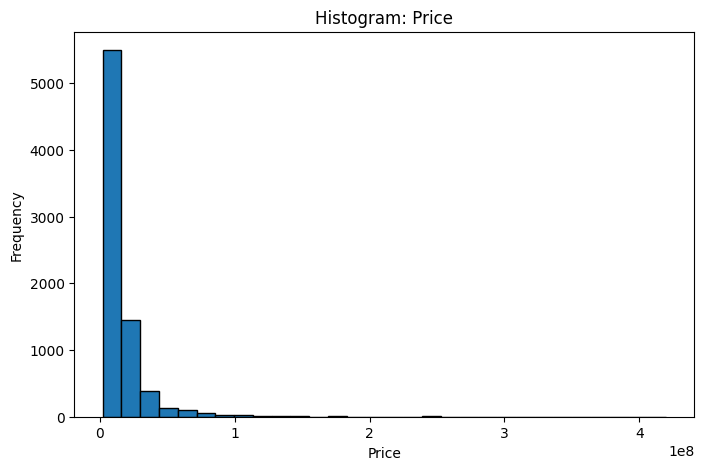

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['Price'], bins=30, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram: Price')
plt.show()

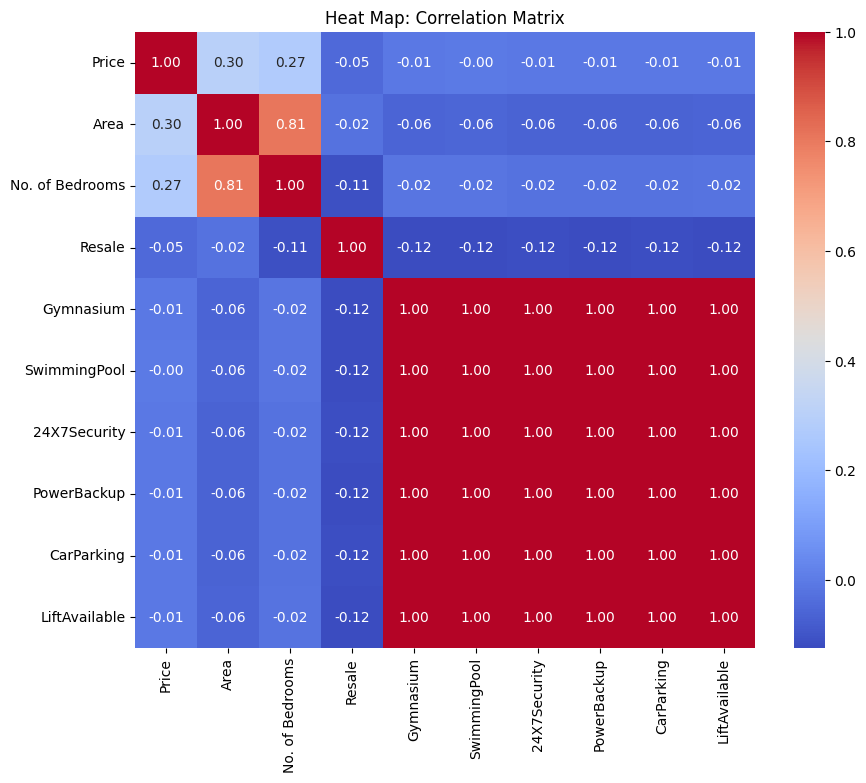

In [9]:
num_cols = ['Price','Area','No. of Bedrooms','Resale','Gymnasium','SwimmingPool','24X7Security','PowerBackup','CarParking','LiftAvailable']
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heat Map: Correlation Matrix')
plt.show()

## 5. Hypothesis testing

In [10]:
pearson_r, pearson_p = stats.pearsonr(df[ind_num], df[dep])
spearman_r, spearman_p = stats.spearmanr(df[ind_num], df[dep])

top_locs = df[ind_cat].value_counts().head(10).index
chi_df = df[df[ind_cat].isin(top_locs)].copy()
chi_df['Price_Category'] = pd.qcut(chi_df[dep], q=4, labels=['Q1','Q2','Q3','Q4'])
cont = pd.crosstab(chi_df[ind_cat], chi_df['Price_Category'])
chi2, chi_p, chi_dof, expected = stats.chi2_contingency(cont)

print('Pearson r =', pearson_r, 'p =', pearson_p)
print('Spearman r =', spearman_r, 'p =', spearman_p)
print('Chi-square =', chi2, 'p =', chi_p, 'dof =', chi_dof)

Pearson r = 0.2991718341624166 p = 2.2721110214843746e-159
Spearman r = 0.33315131592744973 p = 1.9578668932100235e-199
Chi-square = 957.7736627825881 p = 2.0106240081691764e-184 dof = 27


## 6. One-sample t-test

In [11]:
population_mean = df[dep].mean()
shapiro_stat, shapiro_p = stats.shapiro(random_sample[dep])
t_stat, t_p = stats.ttest_1samp(random_sample[dep], population_mean)
print('Population mean:', population_mean)
print('Shapiro-Wilk p-value:', shapiro_p)
print('One-sample t-test statistic:', t_stat)
print('One-sample t-test p-value:', t_p)

Population mean: 15061652.396165306
Shapiro-Wilk p-value: 1.1421219262658288e-19
One-sample t-test statistic: 1.1788416189751914
One-sample t-test p-value: 0.24034030393000202


## 7. Short interpretation
- Price is strongly right-skewed with high-value outliers.
- Area has a positive and statistically significant relationship with Price.
- The random sample mean is not significantly different from the population mean at the 5% level, so it can be treated as broadly representative for the t-test objective.